In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go


In [ ]:
df = pd.read_csv("/data/all_landmark_series_long.csv")
df

,sid,sex,angle_class,landmark,age_idx,age,x,y,dx,dy
0,001,M,Class I,sella,1,6.92,0.0,0.0,NaN,NaN
1,001,M,Class I,sella,2,7.75,0.0,0.0,0.0,0.0
2,001,M,Class I,sella,3,8.50,0.0,0.0,0.0,0.0
3,001,M,Class I,sella,4,9.58,0.0,0.0,0.0,0.0
4,001,M,Class I,sella,5,10.67,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
67264,U98,F,Class I,articular,10,14.00,-15.9,-29.5,-0.4,-5.8
67265,U98,F,Class I,articular,11,15.50,NaN,NaN,NaN,NaN
67266,U98,F,Class I,articular,12,17.00,NaN,NaN,NaN,NaN
67267,U98,F,Class I,articular,13,19.92,NaN,NaN,NaN,NaN


In [3]:
# null value check
df['age'].isnull().sum()
# drop null values
df = df.dropna(subset=['age'])

df['age'].isnull().sum()

0

## create gonion

In [ ]:
## to-do
long_df = pd.read_csv("/data/all_landmark_series_long.csv")
long_df

,sid,sex,angle_class,landmark,age_idx,age,x,y,dx,dy
0,001,M,Class I,sella,1,6.92,0.0,0.0,NaN,NaN
1,001,M,Class I,sella,2,7.75,0.0,0.0,0.0,0.0
2,001,M,Class I,sella,3,8.50,0.0,0.0,0.0,0.0
3,001,M,Class I,sella,4,9.58,0.0,0.0,0.0,0.0
4,001,M,Class I,sella,5,10.67,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
67264,U98,F,Class I,articular,10,14.00,-15.9,-29.5,-0.4,-5.8
67265,U98,F,Class I,articular,11,15.50,NaN,NaN,NaN,NaN
67266,U98,F,Class I,articular,12,17.00,NaN,NaN,NaN,NaN
67267,U98,F,Class I,articular,13,19.92,NaN,NaN,NaN,NaN


In [23]:
import numpy as np
import pandas as pd

def add_average_landmark(
    df: pd.DataFrame,
    upper_name: str = "gonion u",
    lower_name: str = "gonion l",
    new_name: str = "gonion",
    key_cols = ("sid", "sex", "angle_class", "age_idx"),
    age_col: str = "age",
    numeric_cols = ("x", "y", "dx", "dy"),
    age_round_decimals: int = 3,   # helps match 10.670 vs 10.67 etc.
):
    df = df.copy()

    # keep sid as string (important if you have "001")
    if "sid" in df.columns:
        df["sid"] = df["sid"].astype(str).str.strip()

    # split upper/lower
    u = df[df["landmark"] == upper_name].copy()
    l = df[df["landmark"] == lower_name].copy()

    # make a rounded age join key (so age is considered)
    u["_age_key"] = pd.to_numeric(u[age_col], errors="coerce").round(age_round_decimals)
    l["_age_key"] = pd.to_numeric(l[age_col], errors="coerce").round(age_round_decimals)

    merge_keys = list(key_cols) + ["_age_key"]

    # rename numeric cols for merge
    num = [c for c in numeric_cols if c in df.columns]
    u_ren = u.rename(columns={c: f"{c}_u" for c in num})
    l_ren = l.rename(columns={c: f"{c}_l" for c in num})

    m = u_ren.merge(
        l_ren[merge_keys + [f"{c}_l" for c in num] + [age_col]],
        on=merge_keys,
        how="inner",
        suffixes=("", "_lmeta")
    )

    # build new landmark rows (take meta fields from upper)
    new_rows = m[list(key_cols)].copy()
    new_rows[age_col] = m[age_col]  # age from upper (they should match by _age_key)
    new_rows["landmark"] = new_name

    # average numeric values
    for c in num:
        new_rows[c] = (m[f"{c}_u"].astype(float) + m[f"{c}_l"].astype(float)) / 2.0

    # keep column order aligned to original
    new_rows = new_rows[[c for c in df.columns if c in new_rows.columns]]

    # append back (drop helper col if present)
    out = pd.concat([df.drop(columns=["_age_key"], errors="ignore"), new_rows], ignore_index=True)
    return out



In [ ]:
# Usage:
long_df2 = add_average_landmark(long_df, "gonion u", "gonion l", "gonion")
long_df2.to_csv("/data/all_landmark_series_long_with_gonion.csv", index=False)
## need to run code again after adding new landmark

## nearest int bin

In [4]:
def complement_age_bins_as_list(
    df: pd.DataFrame,
    landmark_name: str,
    sid_col: str = "sid",
    age_col: str = "age",
    landmark_col: str = "landmark",
    nonfinite: str = "drop",   # "drop" or "raise"
    decimals: int = 2,
):
    """
    Wide table: sid | age_bin_10 | age_bin_11 | ...
    Each cell stores ALL actual ages that fell into that bin as a comma-separated string.
    Binning: nearest integer via floor(age + 0.5) => 9.7->10, 10.4->10, 10.5->11
    """

    d = df[df[landmark_col] == landmark_name].copy()
    d = d[(d[age_col] >= 9.6) & (d[age_col] <= 18.5)].copy()
    if d.empty:
        raise ValueError(f"No rows found for {landmark_col} == {landmark_name!r}")

    ages = pd.to_numeric(d[age_col], errors="coerce")
    finite_mask = np.isfinite(ages.to_numpy())
    if not finite_mask.all():
        bad = d.loc[~finite_mask, [sid_col, landmark_col, age_col]]
        if nonfinite == "raise":
            raise ValueError(
                f"Found non-finite ages (NaN/inf) for landmark={landmark_name!r}.\n"
                f"{bad.head(20).to_string(index=False)}"
            )
        d = d.loc[finite_mask].copy()
        ages = ages.loc[finite_mask]

    d[age_col] = ages.astype(float)
    d["age_bin"] = np.floor(d[age_col] + 0.5).astype(int)

    # aggregate ages into a sorted, comma-separated string per (sid, bin)
    grouped = (
        d.groupby([sid_col, "age_bin"])[age_col]
         .apply(lambda s: sorted(s.tolist()))
         .unstack()
         .sort_index(axis=1)
         .rename(columns=lambda b: f"age_bin_{int(b)}")
         .reset_index()
    )

    return grouped

In [32]:
## lm point b, pogonion, menton, gonion, condylion

In [5]:
comp = complement_age_bins_as_list(df, landmark_name="point b")
comp

age_bin,sid,age_bin_10,age_bin_11,age_bin_12,age_bin_13,age_bin_14,age_bin_15,age_bin_16,age_bin_17,age_bin_18,age_bin_19
0,001,NaN,[10.67],[11.83],[12.75],[13.83],[14.83],[16.08],NaN,NaN,NaN
1,002,[10.25],[11.33],[12.33],NaN,"[13.58, 14.33]",NaN,[15.5],[16.67],[17.92],NaN
2,003,[9.67],[10.67],[11.67],[12.67],[14.0],[15.25],[16.42],NaN,NaN,NaN
3,004,[9.75],[10.75],[12.0],[12.75],[13.92],[15.08],[16.33],NaN,[17.5],NaN
4,005,[10.33],[11.33],NaN,[12.5],[14.42],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
215,U86,NaN,[10.75],"[11.75, 12.42]",NaN,NaN,NaN,[16.0],[17.08],[18.0],NaN
216,U87,[10.25],[11.25],[12.25],[12.75],[13.75],NaN,[16.0],[17.0],NaN,NaN
217,U94,[9.75],NaN,[11.75],[12.75],NaN,[14.75],NaN,[17.17],NaN,NaN
218,U95,[9.92],[11.17],NaN,[13.0],[14.0],NaN,[16.0],[17.0],NaN,NaN


In [ ]:
comp.to_csv("/data/complement_age_bins.csv", index=False)

Saved histogram to: line_plots/point b_age bin complement histogram_bin0.25_pct.png


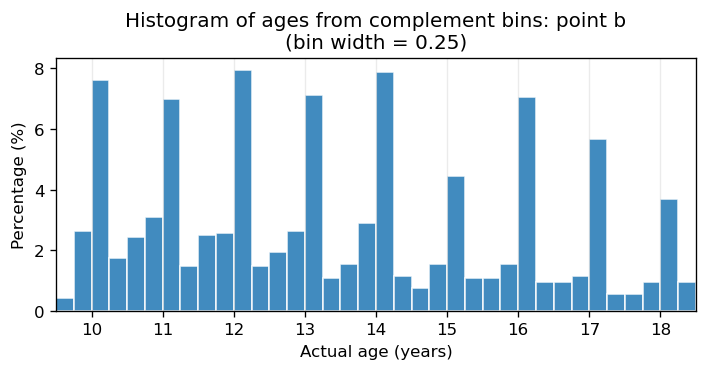

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Histogram of actual ages contained in the complement bins (matplotlib)
# - Collect ages from all `age_bin_*` columns
# - Explode into a long series and plot a histogram

def comp_age_histogram_mpl(comp: pd.DataFrame, landmark_name: str,
                           xmin: float = 9.5, xmax: float = 18.5,
                           bin_width: float = 0.25,
                           width_in: float = 6.0, height_in: float = 3.5,
                           dpi: int = 120,
                           save: bool = False):
    bin_cols = [c for c in comp.columns if c.startswith("age_bin_")]
    if not bin_cols:
        raise ValueError("No age_bin_* columns found in comp")

    long = (
        comp.melt(id_vars=["sid"], value_vars=bin_cols, var_name="bin", value_name="ages")
            .dropna(subset=["ages"])  # drop rows with no ages in that bin
            .explode("ages")           # each age becomes its own row
    )

    long["age"] = long["ages"].astype(float)
    # keep in the expected range
    long = long[(long["age"] >= xmin) & (long["age"] <= xmax)].copy()

    # bins of width 0.25 from xmin to xmax
    # add a tiny epsilon to include xmax due to floating point
    bin_edges = np.arange(xmin, xmax + 1e-9, bin_width)

    # weights so the histogram shows percentage on y-axis
    n = len(long)
    weights = np.full(n, 100.0 / n)

    fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi)
    ax.hist(long["age"], bins=bin_edges, weights=weights,
            color="#1f77b4", alpha=0.85, edgecolor="white")

    # x-axis formatting: ticks at integers 10..18
    ax.set_xlim(xmin, xmax)
    ax.set_xticks(range(10, 19))
    ax.set_xlabel("Actual age (years)")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Histogram of ages from complement bins: {landmark_name}\n(bin width = {bin_width})")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()

    if save:
        out_path = f"line_plots/{landmark_name}_age bin complement histogram_bin{bin_width}_pct.png"
        fig.savefig(out_path)
        print(f"Saved histogram to: {out_path}")

    # show inline
    plt.show()

# Example usage: (reuses existing `comp` in the notebook)
comp_age_histogram_mpl(comp, landmark_name="point b", bin_width=0.25, width_in=6.0, height_in=3.2, dpi=120, save=True)

In [45]:
comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sid         220 non-null    object
 1   age_bin_10  180 non-null    object
 2   age_bin_11  190 non-null    object
 3   age_bin_12  189 non-null    object
 4   age_bin_13  171 non-null    object
 5   age_bin_14  189 non-null    object
 6   age_bin_15  112 non-null    object
 7   age_bin_16  155 non-null    object
 8   age_bin_17  118 non-null    object
 9   age_bin_18  87 non-null     object
 10  age_bin_19  3 non-null      object
dtypes: object(11)
memory usage: 19.0+ KB


In [47]:
comp['age_bin_10'].describe()

count        180
unique        21
top       [10.0]
freq          82
Name: age_bin_10, dtype: object

In [9]:
def comp_bin_plot(comp, landmark_name: str):
    bin_cols = [c for c in comp.columns if c.startswith("age_bin_")]

    long = (comp
            .melt(id_vars="sid", value_vars=bin_cols, var_name="bin", value_name="ages")
            .dropna(subset=["ages"])
            .explode("ages"))

    long["age"] = long["ages"].astype(float)
    long["bin_num"] = long["bin"].str.replace("age_bin_", "", regex=False).astype(int)


    # (optional) keep your 10–18 range
    long = long[(long["age"] >= 9.6) & (long["age"] <= 18.5)].copy()

    # (optional) compute bin if you don't already have it
    long["bin_num"] = np.floor(long["age"] + 0.5).astype(int)


    #plots
    # assume long has columns: sid, age
    long = long[(long["age"] >= 9.6) & (long["age"] <= 18.5)].copy()
    long["bin_num"] = np.floor(long["age"] + 0.5).astype(int)

    sid_order = long.groupby("sid")["age"].min().sort_values().index.tolist()
    sid_to_y = {sid: i for i, sid in enumerate(sid_order)}
    long["y"] = long["sid"].map(sid_to_y)

    xmin, xmax = 9.5, 18.5

    fig = go.Figure()

    # points
    fig.add_trace(go.Scattergl(
        x=long["age"],
        y=long["y"],
        mode="markers",
        marker=dict(size=6, opacity=1),
        customdata=np.stack([long["sid"].astype(str), long["bin_num"]], axis=1),
        hovertemplate="sid=%{customdata[0]}<br>bin=%{customdata[1]}<br>age=%{x:.2f}<extra></extra>",
    ))

    # ---- shapes: horizontal lines (one per sid) + darker vertical bin lines ----
    shapes = []

    # horizontal baseline for each sid row
    N = len(sid_order)

    # 5 horizontal guide lines (evenly spaced)
    y_guides = np.linspace(-0.5, N - 0.5, 5)

    for yg in y_guides:
        shapes.append(dict(
            type="line", x0=xmin, x1=xmax, y0=float(yg), y1=float(yg),
            xref="x", yref="y",
            line=dict(width=1.5, color="rgba(0,0,0,0.30)")
        ))



    # vertical bin lines (darker than before)
    for b in range(10, 19):
        shapes.append(dict(
            type="line", x0=b, x1=b, y0=-0.5, y1=len(sid_order)-0.5,
            xref="x", yref="y",
            line=dict(width=2, color="rgba(0,0,0,0.30)")
        ))

    fig.update_layout(
        shapes=shapes,
        height=max(350, 12 * len(sid_order)),
        xaxis=dict(
            title="Actual age (years)",
            tickmode="linear", tick0=10, dtick=1,
            range=[xmin, xmax],
        ),
        yaxis=dict(title="sids (stacked)", showticklabels=False, range=[-0.5, len(sid_order)-0.5]),
        margin=dict(l=40, r=20, t=30, b=40)
    )
    name ="line_plots/" + landmark_name+"_age bin complement scatter.html"
    fig.update_layout(title_text=f"Age bin complements for landmark: {landmark_name}", title_x=0.5)
    fig.write_html(name)

In [ ]:
landmraks = ["point b", "pogonion", "menton", "condyle"]
for lm in landmraks:
    comp = complement_age_bins_as_list(df, landmark_name=lm)
    comp_bin_plot(comp, landmark_name=lm)


In [11]:
comp

age_bin,sid,age_bin_10,age_bin_11,age_bin_12,age_bin_13,age_bin_14,age_bin_15,age_bin_16,age_bin_17,age_bin_18,age_bin_19
0,001,NaN,[10.67],[11.83],[12.75],[13.83],[14.83],[16.08],NaN,NaN,NaN
1,002,[10.25],[11.33],[12.33],NaN,"[13.58, 14.33]",NaN,[15.5],[16.67],[17.92],NaN
2,003,[9.67],[10.67],[11.67],[12.67],[14.0],[15.25],[16.42],NaN,NaN,NaN
3,004,[9.75],[10.75],[12.0],[12.75],[13.92],[15.08],[16.33],NaN,[17.5],NaN
4,005,[10.33],[11.33],NaN,[12.5],[14.42],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
215,U86,NaN,[10.75],"[11.75, 12.42]",NaN,NaN,NaN,[16.0],[17.08],[18.0],NaN
216,U87,[10.25],[11.25],[12.25],[12.75],[13.75],NaN,[16.0],[17.0],NaN,NaN
217,U94,[9.75],NaN,[11.75],[12.75],NaN,[14.75],NaN,[17.17],NaN,NaN
218,U95,[9.92],[11.17],NaN,[13.0],[14.0],NaN,[16.0],[17.0],NaN,NaN


In [ ]:
# bin_cols = [c for c in comp.columns if c.startswith("age_bin_")]

# long = (comp
#         .melt(id_vars="sid", value_vars=bin_cols, var_name="bin", value_name="ages")
#         .dropna(subset=["ages"])
#         .explode("ages"))

# long["age"] = long["ages"].astype(float)
# long["bin_num"] = long["bin"].str.replace("age_bin_", "", regex=False).astype(int)



# # order sids (pick any ordering you like)
# sid_order = (long.groupby("sid")["age"].min().sort_values().index.tolist())
# sid_to_y = {sid:i for i, sid in enumerate(sid_order)}
# long["y"] = long["sid"].map(sid_to_y)

# fig_h = max(3, len(sid_order) * 0.06)  # minimal spacing; tweak 0.04–0.08
# fig, ax = plt.subplots(figsize=(10, fig_h))

# # dots at actual ages
# ax.scatter(long["age"], long["y"], s=10, alpha=0.45)

# # optional: connect each sid's dots with a tiny line (still 1D-looking)
# for sid, g in long.sort_values("age").groupby("sid"):
#     y = sid_to_y[sid]
#     ax.plot(g["age"], np.full(len(g), y), linewidth=0.6, alpha=0.25)

# # bin guides + bold bin numbers
# ax.set_xlim(9.5, 18.5)
# ax.set_xticks(range(10, 19))
# ax.set_xticklabels([str(i) for i in range(10, 19)], fontweight="bold")
# ax.grid(axis="x", alpha=0.2)

# ax.set_yticks([])              # hide y labels (too many sids)
# ax.set_ylabel("sids (stacked)")
# ax.set_xlabel("Actual age (years)")
# plt.tight_layout()
# plt.show()

## Mae creation

In [19]:
import numpy as np
import pandas as pd

def build_wide_from_preds_and_bins(
    preds_df: pd.DataFrame,      # sid, landmark, sex, age, age_next, x_pred, y_pred, x_true, y_true, ...
    agebin_df: pd.DataFrame,     # sid + age_bin_10..age_bin_18 (cells are lists OR comma-strings)
    landmarks,
    bin_start: int = 10,
    bin_end: int = 18,
    age_round_decimals: int = 3,
    bin_stride: int = 1,
):
    if isinstance(landmarks, str):
        landmarks = [landmarks]
    landmarks = list(landmarks)

    bin_stride = int(bin_stride)
    if bin_stride < 1:
        raise ValueError("bin_stride must be >= 1")

    # ---- 1) pick ONE age per bin per sid (SECOND if multiple) ----
    def to_list(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return []
        if isinstance(v, list):
            return v
        if isinstance(v, str):
            s = v.strip()
            if not s:
                return []
            return [float(x.strip()) for x in s.split(",") if x.strip() != ""]
        return [float(v)]

    def pick_second(v):
        arr = sorted(to_list(v))
        if len(arr) >= 2:
            return float(arr[1])   # SECOND
        if len(arr) == 1:
            return float(arr[0])
        return np.nan

    bin_cols = [f"age_bin_{b}" for b in range(bin_start, bin_end + 1)]
    missing = [c for c in bin_cols if c not in agebin_df.columns]
    if missing:
        raise ValueError(f"agebin_df missing columns: {missing}")

    comp = agebin_df[["sid"] + bin_cols].copy()
    for c in bin_cols:
        comp[c] = comp[c].apply(pick_second)

    # rename to t0,t1,... (these are the chosen actual ages)
    t_list = [f"t{i}" for i in range(bin_end - bin_start + 1)]
    comp = comp.rename(columns={f"age_bin_{b}": f"t{i}" for i, b in enumerate(range(bin_start, bin_end + 1))})
    # ---- 2) base grid: all (sid x landmark) with sex ----
    preds_df["sid"] = preds_df["sid"].astype(str).str.strip()
    comp["sid"] = comp["sid"].astype(str).str.strip()

    # sid -> sex from preds (take first non-missing)
    sex_map = (preds_df[["sid", "sex"]]
            .assign(sex=lambda d: d["sex"].astype(str).str.strip()
                                .replace({"": np.nan, "nan": np.nan, "None": np.nan}))
            .dropna(subset=["sex"])
            .groupby("sid", as_index=False)["sex"].first())

    # base uses preds sids (so sex is coming from preds, not bins)
    base = pd.MultiIndex.from_product([sex_map["sid"].unique(), landmarks],
                                    names=["sid", "landmark"]).to_frame(index=False)

    # attach sex via map (no join weirdness)
    sex_dict = dict(zip(sex_map["sid"], sex_map["sex"]))
    base["sex"] = base["sid"].map(sex_dict)

    # then attach your t0,t1,... ages from comp
    base = base.merge(comp, on="sid", how="left")


    # ---- 3) TRUE coords for each t{i}: match rows where age_next == t{i} ----
    true_lookup = preds_df.loc[preds_df["landmark"].isin(landmarks),
                               ["sid", "landmark", "age_next", "x_true", "y_true"]].copy()
    true_lookup["age_next_r"] = pd.to_numeric(true_lookup["age_next"], errors="coerce").round(age_round_decimals)

    ages_long = base[["sid", "landmark"] + t_list].melt(
        id_vars=["sid", "landmark"], var_name="t", value_name="age_t"
    )
    ages_long["age_t_r"] = pd.to_numeric(ages_long["age_t"], errors="coerce").round(age_round_decimals)

    merged_true = ages_long.merge(
        true_lookup,
        left_on=["sid", "landmark", "age_t_r"],
        right_on=["sid", "landmark", "age_next_r"],
        how="left"
    )

    true_wide_x = merged_true.pivot_table(index=["sid", "landmark"], columns="t", values="x_true", aggfunc="first")
    true_wide_y = merged_true.pivot_table(index=["sid", "landmark"], columns="t", values="y_true", aggfunc="first")
    true_wide_x.columns = [f"{c}x_true" for c in true_wide_x.columns]
    true_wide_y.columns = [f"{c}y_true" for c in true_wide_y.columns]

    # ---- 4) PRED coords into each t{i}: match rows where age == t{i-bin_stride} and age_next == t{i} ----
    pred_lookup = preds_df.loc[preds_df["landmark"].isin(landmarks),
                               ["sid", "landmark", "age", "age_next", "x_pred", "y_pred"]].copy()
    pred_lookup["age_r"] = pd.to_numeric(pred_lookup["age"], errors="coerce").round(age_round_decimals)
    pred_lookup["age_next_r"] = pd.to_numeric(pred_lookup["age_next"], errors="coerce").round(age_round_decimals)
    pred_lookup = pred_lookup.drop_duplicates(["sid", "landmark", "age_r", "age_next_r"], keep="last")

    trans = []
    for i in range(bin_stride, len(t_list)):
        prev_col = t_list[i - bin_stride]
        curr_col = t_list[i]
        tmp = base[["sid", "landmark", prev_col, curr_col]].copy()
        tmp = tmp.rename(columns={prev_col: "age_prev", curr_col: "age_curr"})
        tmp = tmp.dropna(subset=["age_prev", "age_curr"])
        if not tmp.empty:
            tmp["t"] = curr_col  # prediction lands at current time
            trans.append(tmp)

    if not trans:
        raise ValueError("bin_stride is larger than available bins (no transitions possible)")

    trans_long = pd.concat(trans, ignore_index=True)
    trans_long["age_prev_r"] = pd.to_numeric(trans_long["age_prev"], errors="coerce").round(age_round_decimals)
    trans_long["age_curr_r"] = pd.to_numeric(trans_long["age_curr"], errors="coerce").round(age_round_decimals)

    merged_pred = trans_long.merge(
        pred_lookup,
        left_on=["sid", "landmark", "age_prev_r", "age_curr_r"],
        right_on=["sid", "landmark", "age_r", "age_next_r"],
        how="left"
    )

    pred_wide_x = merged_pred.pivot_table(index=["sid", "landmark"], columns="t", values="x_pred", aggfunc="first")
    pred_wide_y = merged_pred.pivot_table(index=["sid", "landmark"], columns="t", values="y_pred", aggfunc="first")
    pred_wide_x.columns = [f"{c}x_pred" for c in pred_wide_x.columns]
    pred_wide_y.columns = [f"{c}y_pred" for c in pred_wide_y.columns]

    # ---- 5) assemble + order columns ----
    out = base.set_index(["sid", "landmark"]).join(true_wide_x).join(true_wide_y).join(pred_wide_x).join(pred_wide_y)
    out = out.reset_index()

    ordered = ["sid", "sex", "landmark"]
    for i in range(len(t_list)):
        ordered += [f"t{i}", f"t{i}x_true", f"t{i}y_true", f"t{i}x_pred", f"t{i}y_pred"]
        for c in ordered:
            if c not in out.columns:
                out[c] = np.nan

    return out[ordered]


Create align

In [ ]:
pred_df = pd.read_csv("./preds/preds_point_b_hop1_deg2_sex_adaptive.csv")
bin_df = pd.read_csv("/data/complement_age_bins.csv")

In [4]:
import ast

# convert bracketed strings like "[10.25]" or "[13.58, 14.33]" into real lists of floats
def _parse_age_bins(df):
    bin_cols = [c for c in df.columns if c.startswith("age_bin_")]

    def parse_cell(v):
        if isinstance(v, list):
            return v
        if pd.isna(v):
            return []
        if isinstance(v, str):
            s = v.strip()
            if not s:
                return []
            if s.startswith("[") and s.endswith("]"):
                try:
                    parsed = ast.literal_eval(s)
                except Exception:
                    inner = s[1:-1]
                    parts = [p.strip() for p in inner.split(",") if p.strip()]
                    return [float(p) for p in parts]
                if isinstance(parsed, (list, tuple)):
                    return [float(x) for x in parsed]
                return [float(parsed)]
            parts = [p.strip() for p in s.split(",") if p.strip()]
            return [float(p) for p in parts] if parts else []
        return [float(v)]

    df = df.copy()
    df[bin_cols] = df[bin_cols].applymap(parse_cell)
    return df

bin_df_clean = _parse_age_bins(bin_df)


C:\Users\alfah\AppData\Local\Temp\ipykernel_37048\4048907380.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[bin_cols] = df[bin_cols].applymap(parse_cell)


In [21]:
from pathlib import Path

landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
name_template = "./preds/predes_{}_2.csv"
out_dir = Path("./align_csvs/hop2")
out_dir.mkdir(parents=True, exist_ok=True)

for lm in landmraks:
    pred_path = name_template.format(lm.replace(" ", "_"))
    pred_df = pd.read_csv(pred_path)
    wide_df = build_wide_from_preds_and_bins(
        preds_df=pred_df,
        agebin_df=bin_df_clean,
        landmarks=[lm],
        bin_stride=2,
    )
    out_path = out_dir / f"{lm.replace(' ', '_')}.xlsx"
    wide_df.to_excel(out_path, index=False)


In [22]:
from pathlib import Path

landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
name_template = "./preds/predes_{}_4.csv"
out_dir = Path("./align_csvs/hop4")
out_dir.mkdir(parents=True, exist_ok=True)

for lm in landmraks:
    pred_path = name_template.format(lm.replace(" ", "_"))
    pred_df = pd.read_csv(pred_path)
    wide_df = build_wide_from_preds_and_bins(
        preds_df=pred_df,
        agebin_df=bin_df_clean,
        landmarks=[lm],
        bin_stride=4,
    )
    out_path = out_dir / f"{lm.replace(' ', '_')}.xlsx"
    wide_df.to_excel(out_path, index=False)


## avg calculation

In [30]:
df = pd.read_excel("./align_csvs/point_b.xlsx")
df.head()

,sid,sex,landmark,t0,t0x_true,t0y_true,t0x_pred,t0y_pred,t1,t1x_true,...,t7,t7x_true,t7y_true,t7x_pred,t7y_pred,t8,t8x_true,t8y_true,t8x_pred,t8y_pred
0,003,M,point b,9.670,NaN,NaN,NaN,NaN,10.670,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,007,F,point b,10.167,NaN,NaN,NaN,NaN,11.250,50.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,008,F,point b,9.750,NaN,NaN,NaN,NaN,10.750,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,013,M,point b,NaN,NaN,NaN,NaN,NaN,10.580,NaN,...,17.000,57.8,-102.3,59.916165,-102.338659,NaN,NaN,NaN,NaN,NaN
4,02286,F,point b,NaN,NaN,NaN,NaN,NaN,11.417,41.9,...,16.583,42.6,-104.7,NaN,NaN,17.5,42.2,-104.8,42.31375,-105.053806


In [11]:
import re
import numpy as np

def add_mae_xyz_and_place(df, base_cols=("sid","sex","landmark"), drop_t0=True):
    out = df.copy()

    t_idx = sorted({
        int(m.group(1))
        for c in out.columns
        for m in [re.match(r"t(\d+)x_true$", c)]
        if m
    })

    for i in t_idx:
        if i == 0:
            if not drop_t0:
                out["t0_mae_x"] = np.nan
                out["t0_mae_y"] = np.nan
                out["t0_mae_xy"] = np.nan
            continue

        xt, yt = f"t{i}x_true", f"t{i}y_true"
        xp, yp = f"t{i}x_pred", f"t{i}y_pred"

        out[f"t{i}_mae_x"]  = (out[xp] - out[xt]).abs()
        out[f"t{i}_mae_y"]  = (out[yp] - out[yt]).abs()
        out[f"t{i}_mae_xy"] = (out[f"t{i}_mae_x"] + out[f"t{i}_mae_y"]) / 2

    # reorder columns: put mae columns right after each time block
    ordered = [c for c in base_cols if c in out.columns]
    for i in t_idx:
        block = [
            f"t{i}",
            f"t{i}x_true", f"t{i}y_true",
            f"t{i}x_pred", f"t{i}y_pred",
        ]
        ordered += [c for c in block if c in out.columns]

        mae_block = [f"t{i}_mae_x", f"t{i}_mae_y", f"t{i}_mae_xy"]
        if i == 0 and drop_t0:
            mae_block = []
        ordered += [c for c in mae_block if c in out.columns]

    remaining = [c for c in out.columns if c not in ordered]
    return out[ordered + remaining]


In [36]:
wide = add_mae_xyz_and_place(df, drop_t0=True)
wide.to_excel("./align_csvs/point_b_with_mae.xlsx", index=False)

In [38]:
landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
for lm in landmraks:
    path = f"./align_csvs/{lm.replace(' ', '_')}.xlsx"
    df = pd.read_excel(path)
    wide = add_mae_xyz_and_place(df, drop_t0=True)
    out_path = f"./align_csvs/{lm.replace(' ', '_')}_with_mae.xlsx"
    wide.to_excel(out_path, index=False)

In [40]:
landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
for lm in landmraks:
    path = f"./align_csvs/{lm.replace(' ', '_')}_with_mae.xlsx"
    df = pd.read_excel(path)
    male = df[df['sex'] == 'M']
    female = df[df['sex'] == 'F']
    out_path_male = f"./align_csvs/{lm.replace(' ', '_')}_male_with_mae.xlsx"
    out_path_female = f"./align_csvs/{lm.replace(' ', '_')}_female_with_mae.xlsx"

    male.to_excel(out_path_male, index=False)
    female.to_excel(out_path_female, index=False)

hop 2


In [23]:
landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
for lm in landmraks:
    path = f"./align_csvs/hop2/{lm.replace(' ', '_')}.xlsx"
    df = pd.read_excel(path)
    wide = add_mae_xyz_and_place(df, drop_t0=True)
    out_path = f"./align_csvs/hop2/mae/{lm.replace(' ', '_')}_with_mae.xlsx"
    wide.to_excel(out_path, index=False)

landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
for lm in landmraks:
    path = f"./align_csvs/hop2/mae/{lm.replace(' ', '_')}_with_mae.xlsx"
    df = pd.read_excel(path)
    male = df[df['sex'] == 'M']
    female = df[df['sex'] == 'F']
    out_path_male = f"./align_csvs/hop2/male/{lm.replace(' ', '_')}_male_with_mae.xlsx"
    out_path_female = f"./align_csvs/hop2/female/{lm.replace(' ', '_')}_female_with_mae.xlsx"

    male.to_excel(out_path_male, index=False)
    female.to_excel(out_path_female, index=False)

hop 4

In [24]:
landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
for lm in landmraks:
    path = f"./align_csvs/hop4/{lm.replace(' ', '_')}.xlsx"
    df = pd.read_excel(path)
    wide = add_mae_xyz_and_place(df, drop_t0=True)
    out_path = f"./align_csvs/hop4/mae/{lm.replace(' ', '_')}_with_mae.xlsx"
    wide.to_excel(out_path, index=False)

landmraks = ["point b", "pogonion", "menton", "condyle", "gonion"]
for lm in landmraks:
    path = f"./align_csvs/hop4/mae/{lm.replace(' ', '_')}_with_mae.xlsx"
    df = pd.read_excel(path)
    male = df[df['sex'] == 'M']
    female = df[df['sex'] == 'F']
    out_path_male = f"./align_csvs/hop4/male/{lm.replace(' ', '_')}_male_with_mae.xlsx"
    out_path_female = f"./align_csvs/hop4/female/{lm.replace(' ', '_')}_female_with_mae.xlsx"

    male.to_excel(out_path_male, index=False)
    female.to_excel(out_path_female, index=False)